# 🔮 ETH Price Prediction
## Simple Forecasting Models

This notebook uses various forecasting methods to predict ETH prices.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 2. Load Data

In [2]:
# Load data from SQLite
DATA_DIR = Path('..') / 'data'
db_path = DATA_DIR / 'ETH.db'

conn = sqlite3.connect(db_path)
df = pd.read_sql("SELECT * FROM eth_ohlcv ORDER BY date", conn, parse_dates=['date'])
conn.close()

print(f"✅ Loaded {len(df)} days of data")
df.tail()

✅ Loaded 365 days of data


,date,open,high,low,close,volume,SMA_7,SMA_20,SMA_50,EMA_12,EMA_26,MACD,MACD_signal,MACD_histogram,RSI_14,BB_middle,BB_upper,BB_lower,ATR_14
360,2026-07-23,1934.26,1941.50,1869.44,1878.38,219789.0733,1889.180000,1834.6415,1735.5782,1868.852092,1823.166917,45.685175,37.254713,8.430462,64.018436,1834.6415,1959.304306,1709.978694,64.901429
361,2026-07-24,1878.38,1909.80,1848.09,1861.44,200795.4361,1891.967143,1838.6815,1737.3916,1867.711770,1826.001960,41.709810,38.145732,3.564078,57.332940,1838.6815,1961.194174,1716.168826,64.000714
362,2026-07-25,1861.44,1877.07,1851.22,1874.89,88434.4880,1893.721429,1843.1435,1743.2214,1868.816113,1829.623297,39.192816,38.355149,0.837668,59.794950,1843.1435,1964.013124,1722.273876,62.745714
363,2026-07-26,1874.88,1967.36,1873.85,1954.72,153233.6949,1905.505714,1850.9015,1750.9220,1882.032096,1838.889719,43.142377,39.312594,3.829782,64.629322,1850.9015,1979.653425,1722.149575,66.035000
364,2026-07-27,1954.72,1981.24,1936.51,1965.49,129487.7176,1914.180000,1860.6035,1756.4216,1894.871773,1848.267518,46.604256,40.770927,5.833329,69.410797,1860.6035,1993.329124,1727.877876,62.387143


## 3. Simple Moving Average Forecast

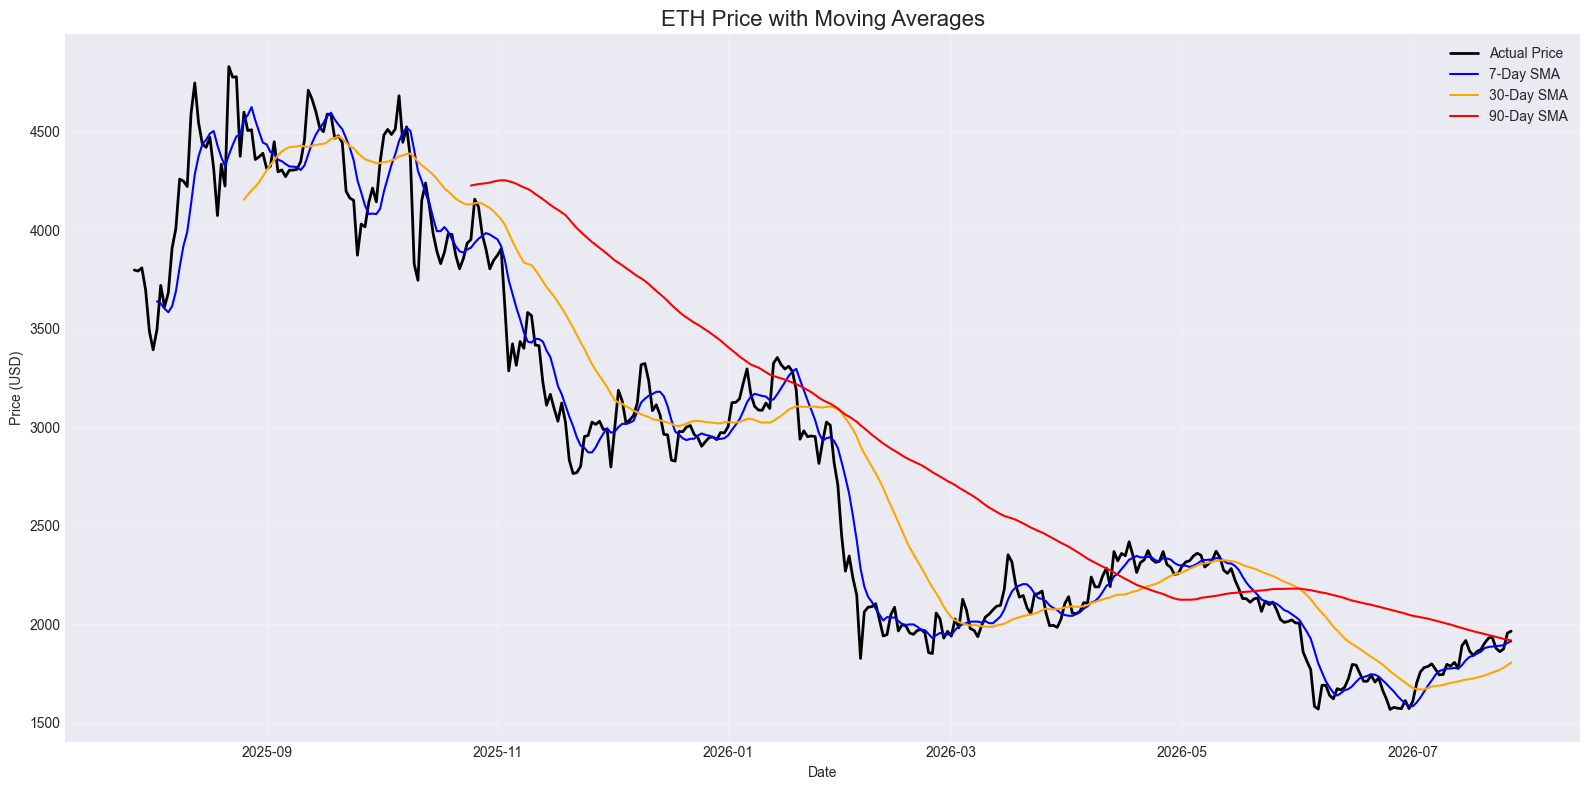

In [3]:
# Calculate moving averages
df['SMA_7'] = df['close'].rolling(7).mean()
df['SMA_30'] = df['close'].rolling(30).mean()
df['SMA_90'] = df['close'].rolling(90).mean()

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(df['date'], df['close'], label='Actual Price', color='black', linewidth=2)
ax.plot(df['date'], df['SMA_7'], label='7-Day SMA', color='blue', linewidth=1.5)
ax.plot(df['date'], df['SMA_30'], label='30-Day SMA', color='orange', linewidth=1.5)
ax.plot(df['date'], df['SMA_90'], label='90-Day SMA', color='red', linewidth=1.5)

ax.set_title('ETH Price with Moving Averages', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()